# Topic modeling

## 0. Libraries import

In [1]:
import pandas as pd
import numpy as np
import ast
import gensim
import gensim.corpora as corpora
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nltk
import string 
import re
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [2]:
from gensim.models import LdaModel
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from collections import Counter
from gensim.models import CoherenceModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score

## 1. Data import

In [3]:
DATA_PATH = "kickstarter_processed.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(6507, 15)


,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency,category,video,reached,status,duration,description_processed,pos_tagged
0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,71123.0,61607,48000.0,USD,Film & Video,1,148.172917,1,30,"['problem', 'much', 'entertainment', 'today', ...","[('problem', 'NN'), ('much', 'JJ'), ('entertai..."
1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,65318.0,56579,61500.0,USD,Film & Video,1,106.208130,1,41,"['million', 'american', 'college', 'student', ...","[('million', 'CD'), ('american', 'JJ'), ('coll..."
2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,462.0,400,8000.0,USD,Film & Video,1,5.775000,0,45,"['full', 'z', 'set', 'launch', 'set', 'show', ...","[('full', 'JJ'), ('z', 'NN'), ('set', 'VBN'), ..."
3,https://www.kickstarter.com/projects/jordym/th...,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,5137.0,4449,15000.0,USD,Film & Video,1,34.246667,0,60,"['sleepy', 'summer', 'afternoon', 'star', 'voi...","[('sleepy', 'NN'), ('summer', 'NN'), ('afterno..."
4,https://www.kickstarter.com/projects/trans-mov...,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50640.0,43865,50000.0,USD,Film & Video,1,101.280000,1,30,"['hour', 'pledge', 'match', 'amaze', 'news', '...","[('hour', 'NN'), ('pledge', 'NN'), ('match', '..."


## 2. Latent Dirichlet Analysis (LDA)

### 2.1 Bag of Words creation

The Bag of Words representation is constructed separately for each category in order to capture category specific vocabulary and thematic structures. Text data are first tokenized using the preprocessed descriptions, after which a dictionary is created for each subset of documents. However, to improve the quality of the representation and reduce noise, extreme terms are filtered out by removing words that appear in fewer than five documents and those occurring in more than 40% of the documents within the same category. Although a preliminary filtering step was already performed during data preparation to remove globally rare and overly frequent terms, an additional category-level filtering is necessary. In fact, certain words may not be excessively frequent across the entire dataset but can still dominate within a specific category, thereby reducing their discriminative power (e.g. *movie* in *Film & Video* category). By applying filtering within each category, such locally frequent terms are effectively removed, allowing the model to focus on more meaningful and distinctive patterns.

In [4]:
categories = df['category'].unique()

results = []
dictionaries_by_category = {}
corpora_by_category = {}

for cat in categories:
    df_cat = df[df['category'] == cat]

    # Tokenization
    texts_cat = df_cat['description_processed'].apply(lambda x: x.split()).tolist()

    # Category dictionary 
    dictionary_cat = Dictionary(texts_cat)

    vocab_before = len(dictionary_cat)

    # Removing words that appear in more than 40% of documents and in less than 5 documents 
    dictionary_cat.filter_extremes(no_below = 5, no_above = 0.4)

    vocab_after = len(dictionary_cat)

    # Bag of Words creation
    corpus_cat = [dictionary_cat.doc2bow(text) for text in texts_cat]

    dictionaries_by_category[cat] = dictionary_cat
    corpora_by_category[cat] = corpus_cat

    results.append({
        "Category": cat,
        "Documents": len(texts_cat),
        "Vocab before filtering": vocab_before,
        "Vocab after filtering": vocab_after,
        "Removed words": vocab_before - vocab_after
    })

bow_summary = pd.DataFrame(results)
bow_summary

,Category,Documents,Vocab before filtering,Vocab after filtering,Removed words
0,Film & Video,1834,17150,10187,6963
1,Games,1115,15797,8150,7647
2,Music,1112,13485,5284,8201
3,Publishing,1088,15655,7501,8154
4,Technology,1358,14468,7423,7045


### 2.2 Coherence scores

#### Coherence scores computation

Coherence scores are computed to guide the selection of the optimal number of topics for each category. In fact, since Latent Dirichlet Allocation (LDA) does not provide a predefined criterion for determining the number of topics, different values of (k) are tested within a specified range. Therefore, for each configuration, a topic model is trained independently on the corresponding category-specific corpus and the coherence score (C_V) is calculated. The C_V metric is adopted as the primary evaluation measure, as it evaluates the degree of semantic similarity between the high-probability words within each topic, providing an indication of how meaningful and coherent the extracted topics are. Finally, the resulting table reports coherence scores across different values of (k) for each category, enabling a comparative analysis of model quality. 

In [5]:
topic_range = range(2, 9)

coherence_results = []
lda_models_by_category = {}

for cat in categories:
    dictionary_cat = dictionaries_by_category[cat]
    corpus_cat = corpora_by_category[cat]

    df_cat = df[df['category'] == cat]
    texts_cat = df_cat['description_processed'].apply(lambda x: x.split()).tolist()

    lda_models_by_category[cat] = {}

    for k in topic_range:
        lda_model = LdaMulticore(
            corpus = corpus_cat,
            id2word = dictionary_cat,
            num_topics = k,
            passes = 10,
            workers = 2,
            random_state = 11
        )

        coherence_cv = CoherenceModel(
            model = lda_model,
            texts = texts_cat,
            dictionary = dictionary_cat,
            coherence = 'c_v'
        ).get_coherence()

        lda_models_by_category[cat][k] = lda_model

        coherence_results.append({
            "Category": cat,
            "Topics (k)": k,
            "C_V": coherence_cv
        })

# DataFrame
cv_summary = pd.DataFrame(coherence_results)

cv_summary = cv_summary.sort_values(
    by = ["Category", "Topics (k)"]
).reset_index(drop = True)

cv_pivot = cv_summary.pivot(
    index = "Category",
    columns = "Topics (k)",
    values = "C_V"
)

cv_pivot.round(4)

Topics (k),2,3,4,5,6,7,8
Category,,,,,,,
Film & Video,0.4303,0.3914,0.3736,0.3598,0.3552,0.3549,0.3506
Games,0.3825,0.3759,0.3696,0.4041,0.3890,0.3929,0.3834
Music,0.3487,0.3689,0.4031,0.3972,0.3634,0.4098,0.3844
Publishing,0.4106,0.3793,0.4735,0.4591,0.4286,0.4230,0.4348
Technology,0.3117,0.3733,0.3860,0.4100,0.4244,0.4245,0.4151


Based on the computed coherence scores, the optimal number of topics is selected for each category by identifying the value of k that maximizes the C_V metric. The resulting table summarizes the best-performing configuration for each category, highlighting the corresponding coherence score.

In [6]:
best_k = cv_summary.loc[
    cv_summary.groupby("Category")["C_V"].idxmax()
][["Category", "Topics (k)", "C_V"]]

best_k = best_k.rename(columns={"Topics (k)": "Best k"}).round(4)

best_k

,Category,Best k,C_V
0,Film & Video,2,0.4303
10,Games,5,0.4041
19,Music,7,0.4098
23,Publishing,4,0.4735
33,Technology,7,0.4245


#### Coherence scores visualization

The coherence score trends across different number of topics are visualized for each category in order to support the selection of the optimal value of k. Each plot illustrates how the C_V metric varies as the number of topics increases, with the best-performing configuration highlighted. Overall, these visualizations confirm that the selected values of k correspond to the local maximum of the coherence score and provide a reasonable balance between model complexity and interpretability.

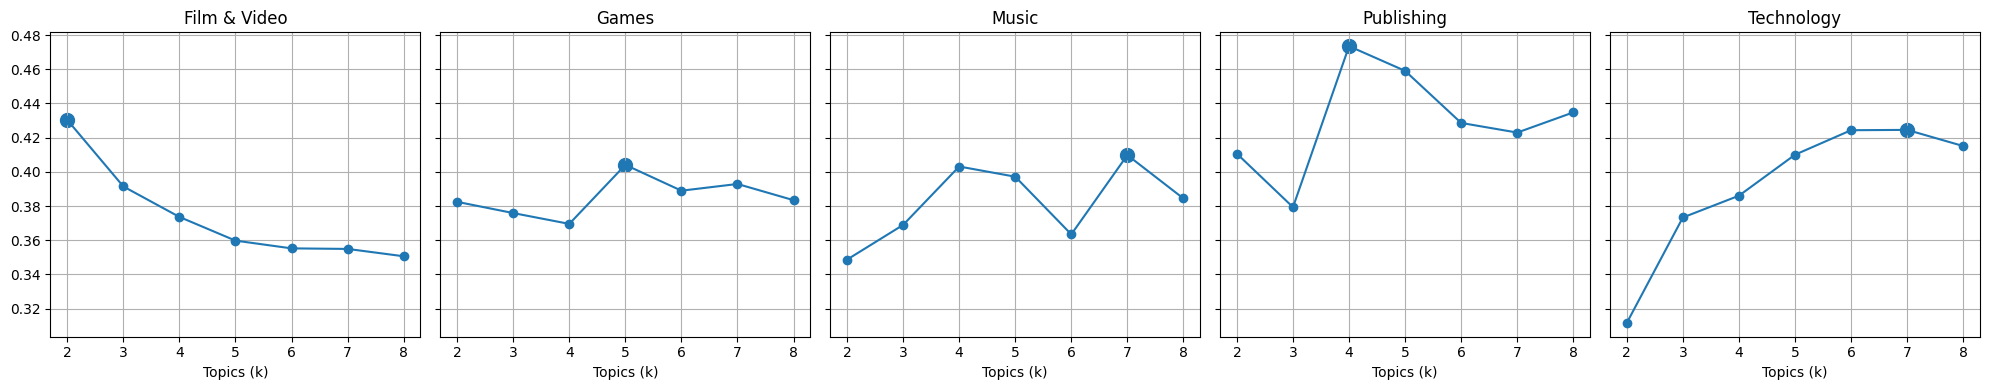

In [7]:
categories_order = cv_summary["Category"].unique()

fig, axes = plt.subplots(
    1,
    len(categories_order),
    figsize = (20, 4),  
    sharex = True,
    sharey = True       
)

for i, cat in enumerate(categories_order):
    ax = axes[i]
    
    data_cat = cv_summary[
        cv_summary["Category"] == cat
    ].sort_values("Topics (k)")
    
    ax.plot(data_cat["Topics (k)"], data_cat["C_V"], marker = "o")
    
    # best number of topics
    best_row = data_cat.loc[data_cat["C_V"].idxmax()]
    ax.scatter(best_row["Topics (k)"], best_row["C_V"], s = 100)
    
    ax.set_title(cat)
    ax.set_xlabel("Topics (k)")
    ax.grid(True)

plt.tight_layout()
plt.show()

### 2.3 Identification of the main topics

#### Latent Dirichlet Allocation (LDA)

After selecting the optimal number of topics for each category, a final LDA model is trained separately on each category-specific corpus using the corresponding best value of k. This allows the topic extraction process to account for the different thematic structures and vocabulary distributions observed across categories, in fact, for each trained model, the most representative words are extracted for every topic. Specifically, the top 15 words with the highest probability within each topic are selected and stored in a structured table. The results are then displayed separately for each category, together with the selected number of topics, in order to make the output easier to inspect and compare. A preliminary inspection of the extracted topics suggests that their level of distinctiveness varies across categories. In some cases, topics appear well separated, with clearly differentiated sets of words, while in others a certain degree of overlap can be observed, indicating that some themes share a common vocabulary.

In [9]:
topic_words_results = []

for _, row in best_k.iterrows():
    cat = row["Category"]
    k = int(row["Best k"])

    dictionary_cat = dictionaries_by_category[cat]
    corpus_cat = corpora_by_category[cat]

    lda_model = LdaMulticore(
        corpus = corpus_cat,
        id2word = dictionary_cat,
        num_topics = k,
        passes = 10,
        workers = 2,
        random_state = 11
    )

    for topic_id in range(k):
        words = lda_model.show_topic(topic_id, topn = 15)  
        top_words = ", ".join([word for word, weight in words])

        topic_words_results.append({
            "Category": cat,
            "Topic": topic_id + 1,
            "Top words": top_words
        })

topics_table = pd.DataFrame(topic_words_results)

topics_table = topics_table.sort_values(
    by = ["Category", "Topic"]
).reset_index(drop=True)

for cat in topics_table["Category"].unique():
    k = int(best_k[best_k["Category"] == cat]["Best k"].values[0])
    
    display(
        topics_table[topics_table["Category"] == cat][["Topic", "Top words"]]
        .style.set_caption(f"{cat} — {k} topics")
    )

,Topic,Top words
0,1,"'award',, 'actor',, 'writer',, 'woman',, 'documentary',, 'filmmaker',, 'school',, 'artist',, 'win',, 'york',, 'direct',, 'family',, 'series',, 'american',, 'university',"
1,2,"'reward',, 'series',, 'episode',, 'video',, 'animation',, 'community',, 'backer',, 'cost',, 'pledge',, 'money',, 'digital',, 'reach',, 'budget',, 'thank',, 'right',"


,Topic,Top words
2,1,"'content',, 'controller',, 'sound',, 'system',, 'app',, 'product',, 'video',, 'button',, 'development',, 'device',, 'control',, 'user',, 'console',, 'n',, 'switch',"
3,2,"'card',, 'deck',, 'dice',, 'box',, 'tarot',, 'shipping',, 'edition',, 'book',, 'print',, 'rule',, 'color',, 'order',, 'expansion',, 'board',, 'pack',"
4,3,"'book',, 'digital',, 'dice',, 'adventure',, 'table',, 'print',, 'tier',, 'monster',, 'fantasy',, 'pdf',, 'map',, 'item',, 'system',, 'shipping',, 'edition',"
5,4,"'puzzle',, 'piece',, 'book',, 'crossword',, 'board',, 'print',, 'solve',, 'color',, 'page',, 'artist',, 'tier',, 'name',, 'dance',, 'thing',, 'kid',"
6,5,"'battle',, 'system',, 'tier',, 'adventure',, 'development',, 'skill',, 'item',, 'event',, 'enemy',, 'ability',, 'gameplay',, 'learn',, 'access',, 'release',, 'combat',"


,Topic,Top words
7,1,"'n',, 'jazz',, 'art',, 'student',, 'piano',, 'festival',, 'event',, 'musical',, 'inspire',, 'home',, 'book',, 'school',, 'program',, 'hop',, 'workshop',"
8,2,"'day',, 'tour',, 'feel',, 'dream',, 'band',, 'show',, 'guitar',, 'hope',, 'producer',, 'full',, 'last',, 'thing',, 'best',, 'family',, 'journey',"
9,3,"'money',, 'ep',, 'show',, 'full',, 'thing',, 'best',, 'day',, 'band',, 'great',, 'reach',, 'really',, 'process',, 'put',, 'good',, 'raise',"
10,4,"'band',, 'vinyl',, 'track',, 'jazz',, 'set',, 'original',, 'press',, 'engineer',, 'art',, 'cover',, 'vocal',, 'bass',, 'full',, 'edition',, 'session',"
11,5,"'god',, 'church',, 'worship',, 'sing',, 'jesus',, 'hope',, 'begin',, 'heart',, 'great',, 'believe',, 'book',, 'family',, 'faith',, 'call',, 'producer',"
12,6,"'shirt',, 'radio',, 'reach',, 'great',, 'money',, 'god',, 'produce',, 'receive',, 'pay',, 'thing',, 'day',, 'put',, 'ask',, 'may',, 'believe',"
13,7,"'composer',, 'perform',, 'jazz',, 'musical',, 'concert',, 'piece',, 'performance',, 'orchestra',, 'art',, 'ensemble',, 'film',, 'piano',, 'classical',, 'american',, 'award',"


,Topic,Top words
14,1,"'woman',, 'deck',, 'change',, 'card',, 'learn',, 'self',, 'community',, 'plan',, 'thing',, 'build',, 'become',, 'guide',, 'good',, 'say',, 'china',"
15,2,"'child',, 'community',, 'family',, 'kid',, 'learn',, 'show',, 'little',, 'series',, 'music',, 'magazine',, 'school',, 'reader',, 'illustration',, 'young',, 'thank',"
16,3,"'edition',, 'add',, 'ship',, 'backer',, 'pledge',, 'tier',, 'sign',, 'copy',, 'artist',, 'special',, 'stretch',, 'hardcover',, 'receive',, 'color',, 'digital',"
17,4,"'magazine',, 'fiction',, 'writer',, 'anthology',, 'award',, 'issue',, 'editor',, 'poetry',, 'black',, 'artist',, 'short',, 'press',, 'word',, 'fantasy',, 'collection',"


,Topic,Top words
18,1,"'camera',, 'battery',, 'charge',, 'light',, 'quality',, 'phone',, 'pro',, 'usb',, 'watch',, 'color',, 'hand',, 'sound',, 'mount',, 'app',, 'smartphone',"
19,2,"'sound',, 'audio',, 'music',, 'speaker',, 'sleep',, 'bluetooth',, 'headphone',, 'quality',, 'app',, 'body',, 'track',, 'band',, 'fit',, 'ear',, 'data',"
20,3,"'sensor',, 'kit',, 'board',, 'robot',, 'software',, 'learn',, 'program',, 'open',, 'battery',, 'hardware',, 'data',, 'prototype',, 'student',, 'pi',, 'run',"
21,4,"'game',, 'space',, 'module',, 'kit',, 'model',, 'board',, 'motion',, '3d',, 'mode',, 'controller',, 'reward',, 'program',, 'mission',, 'light',, 'input',"
22,5,"'print',, 'light',, '3d',, 'cut',, 'clean',, 'material',, 'machine',, 'sound',, 'water',, 'printer',, 'box',, 'laser',, 'browser',, 'precision',, 'html5',"
23,6,"'app',, 'learn',, 'sound',, 'home',, 'community',, 'family',, 'child',, 'content',, 'pet',, 'kid',, 'dog',, 'would',, 'grow',, 'day',, 'browser',"
24,7,"'app',, 'platform',, 'community',, 'access',, 'business',, 'launch',, 'real',, 'data',, 'event',, 'content',, 'live',, 'social',, 'challenge',, 'journey',, 'reward',"


#### Topic quality measurement

Topic diversity is computed to quantitatively assess how distinct the extracted topics are within each category. In fact, for each category, the final LDA model is used to retrieve the top words associated with each topic, specifically, for every topic, the top 15 most probable words are extracted. These words are then aggregated across all topics within the same category and the number of unique terms is computed. Topic diversity is defined as the ratio between the number of unique words and the total number of words considered (i.e. the number of topics multiplied by the number of top words per topic). This metric provides an indication of how much overlap exists between topics: higher values correspond to more distinct topics with less shared vocabulary, while lower values suggest greater redundancy and overlap among topics. The resulting table summarizes, for each category, the selected number of topics and the corresponding diversity score.

In [10]:
num_words = 15

diversity_results = []

for _, row in best_k.iterrows():
    cat = row["Category"]
    k = int(row["Best k"])

    lda_model = lda_models_by_category[cat][k]

    topic_words = []

    for topic_id in range(k):
        words = lda_model.show_topic(topic_id, topn = num_words)
        topic_words.append([word for word, weight in words])

    unique_words = set()

    for topic in topic_words:
        unique_words.update(topic)

    total_words = num_words * k
    topic_diversity = len(unique_words) / total_words

    diversity_results.append({
        "Category": cat,
        "Best k": k,
        "Top words per topic": num_words,
        "Unique words": len(unique_words),
        "Total words": total_words,
        "Topic diversity": topic_diversity
    })

diversity_table = pd.DataFrame(diversity_results)

diversity_table[[
    "Category",
    "Best k",
    "Unique words",
    "Total words",
    "Topic diversity"
]].round(4)

,Category,Best k,Unique words,Total words,Topic diversity
0,Film & Video,2,29,30,0.9667
1,Games,5,59,75,0.7867
2,Music,7,78,105,0.7429
3,Publishing,4,56,60,0.9333
4,Technology,7,84,105,0.8000


#### LDA topic visualization (pyLDAvis)

The pyLDAvis visualizations provide a graphical representation of the topic structure within each category. The intertopic distance map highlights how topics are positioned in a two-dimensional space, where the distance between circles reflects their dissimilarity. In several cases, some topics appear well separated, indicating clearly distinct thematic areas, while others are closer or partially overlapping, suggesting a degree of similarity in their word distributions. The size of each circle reflects the relative prevalence of the corresponding topic within the corpus. In some categories, a few dominant topics can be observed, while others are more evenly distributed. The bar charts on the right show the most salient terms for each topic, allowing for a clearer understanding of the vocabulary driving the topic formation. In general, the visualizations confirm previous observations: categories with more heterogeneous vocabularies tend to exhibit better topic separation, whereas categories with more homogeneous language show greater overlap between topics. Overall, these visual tools support the interpretation of the LDA results by providing insight into both the distinctiveness and the relative importance of the extracted topics.

In [11]:
for _, row in best_k.iterrows():
    cat = row["Category"]
    k = int(row["Best k"])

    lda_model = lda_models_by_category[cat][k]
    corpus_cat = corpora_by_category[cat]
    dictionary_cat = dictionaries_by_category[cat]

    print(f"\npyLDAvis for {cat} — {k} topics")

    lda_vis = gensimvis.prepare(
        lda_model,
        corpus_cat,
        dictionary_cat
    )

    display(pyLDAvis.display(lda_vis))


pyLDAvis for Film & Video — 2 topics



pyLDAvis for Games — 5 topics



pyLDAvis for Music — 7 topics



pyLDAvis for Publishing — 4 topics



pyLDAvis for Technology — 7 topics


## 3. Topic analysis across documents

### 3.1 Topic distribution and dominant topic assignment

In [ ]:
topic_rows = []

for _, row in best_k.iterrows():
    cat = row["Category"]
    k = int(row["Best k"])

    lda_model = lda_models_by_category[cat][k]
    corpus_cat = corpora_by_category[cat]

    for doc_id, doc_topics in enumerate(lda_model[corpus_cat]):
        doc_row = {
            "Category": cat,
            "Doc ID": doc_id
        }

        # set initial probabilities to 0
        for i in range(k):
            doc_row[f"Topic {i} Prob"] = 0

        # assign actual probabilities
        for topic_id, prob in doc_topics:
            doc_row[f"Topic {topic_id} Prob"] = prob

        # assign dominant topic 
        dominant_topic = max(doc_topics, key=lambda x: x[1])[0]
        doc_row["Dominant Topic"] = dominant_topic

        topic_rows.append(doc_row)

topic_dist_table = pd.DataFrame(topic_rows)

topic_dist_table[[
    "Category",
    "Doc ID",
    "Dominant Topic"
]].head(20)

,Category,Doc ID,Dominant Topic
0,Film & Video,0,1
1,Film & Video,1,0
2,Film & Video,2,1
3,Film & Video,3,0
4,Film & Video,4,0
5,Film & Video,5,0
6,Film & Video,6,1
7,Film & Video,7,1
8,Film & Video,8,1
9,Film & Video,9,1


### 3.2 Identification of representative documents per topic

In [29]:
top_docs_rows = []
n_top = 3

for _, row in best_k.iterrows():
    cat = row["Category"]
    k = int(row["Best k"])

    category_docs = topic_dist_table[
        topic_dist_table["Category"] == cat
    ]

    for topic_id in range(k):
        col = f"Topic {topic_id} Prob"

        top_docs = category_docs.sort_values(
            by = col,
            ascending = False
        ).head(n_top)

        for _, doc_row in top_docs.iterrows():
            top_docs_rows.append({
                "Category": cat,
                "Topic": topic_id,
                "Doc ID": doc_row["Doc ID"],
                "Probability": round(doc_row[col], 3)
            })

top_docs_table = pd.DataFrame(top_docs_rows)

top_docs_table = top_docs_table.sort_values(
    by = ["Category", "Topic", "Probability"],
    ascending = [True, True, False]
).reset_index(drop = True)

for cat in top_docs_table["Category"].unique():
    display(
        top_docs_table[top_docs_table["Category"] == cat][
            ["Topic", "Doc ID", "Probability"]
        ].style.set_caption(f"Representative documents for {cat}")
    )

,Topic,Doc ID,Probability
0,0,217,0.999000
1,0,36,0.999000
2,0,966,0.999000
3,1,675,1.000000
4,1,1144,0.999000
5,1,452,0.999000


,Topic,Doc ID,Probability
6,0,340,0.999000
7,0,54,0.999000
8,0,660,0.999000
9,1,802,0.999000
10,1,19,0.999000
11,1,128,0.999000
12,2,215,1.000000
13,2,836,0.999000
14,2,882,0.999000
15,3,946,0.999000


,Topic,Doc ID,Probability
21,0,653,0.999000
22,0,578,0.999000
23,0,900,0.998000
24,1,527,0.999000
25,1,353,0.998000
26,1,676,0.998000
27,2,633,0.999000
28,2,13,0.998000
29,2,200,0.998000
30,3,245,0.999000


,Topic,Doc ID,Probability
42,0,406,1.000000
43,0,1075,1.000000
44,0,138,0.999000
45,1,613,0.999000
46,1,146,0.999000
47,1,535,0.999000
48,2,964,1.000000
49,2,438,0.999000
50,2,627,0.999000
51,3,159,0.999000


,Topic,Doc ID,Probability
54,0,280,0.999000
55,0,333,0.999000
56,0,574,0.999000
57,1,93,0.999000
58,1,1063,0.999000
59,1,1336,0.999000
60,2,56,0.999000
61,2,276,0.999000
62,2,587,0.999000
63,3,1184,0.999000


### 3.3 Project success across topics

In [ ]:
topic_dist_table["status"] = None

for cat in topic_dist_table["Category"].unique():
    status_values = (
        df[df["category"] == cat]["status"]
        .reset_index(drop = True)
        .values
    )

    topic_dist_table.loc[
        topic_dist_table["Category"] == cat,
        "status"
    ] = status_values

topic_success = (
    topic_dist_table
    .groupby(["Category", "Dominant Topic", "status"])
    .size()
    .unstack(fill_value = 0)
    .reset_index()
)

topic_success = topic_success.rename(columns = {
    0: "Failed",
    1: "Successful"
})

topic_success["Total Documents"] = (
    topic_success["Failed"] + topic_success["Successful"]
)

topic_success["Success Rate"] = (
    topic_success["Successful"] / topic_success["Total Documents"]
).round(3)

topic_success = topic_success[
    [
        "Category",
        "Dominant Topic",
        "Total Documents",
        "Successful",
        "Failed",
        "Success Rate"
    ]
].sort_values(
    by = ["Category", "Dominant Topic"]
).reset_index(drop = True)

topic_success

status,Category,Dominant Topic,Total Documents,Successful,Failed,Success Rate
0,Film & Video,0,809,578,231,0.714
1,Film & Video,1,1025,595,430,0.580
2,Games,0,136,58,78,0.426
3,Games,1,290,210,80,0.724
4,Games,2,172,124,48,0.721
5,Games,3,170,105,65,0.618
6,Games,4,347,176,171,0.507
7,Music,0,51,27,24,0.529
8,Music,1,414,351,63,0.848
9,Music,2,205,165,40,0.805


## 4 Logistic regression

### 4.1 Logistic regression with topic features only

In [ ]:
results = []

for cat in topic_dist_table["Category"].unique():
    
    df_cat = topic_dist_table[
        topic_dist_table["Category"] == cat
    ].copy()
    
    # colonne probabilità
    prob_cols = [col for col in df_cat.columns if "Prob" in col]
    
    X = df_cat[prob_cols].fillna(0)
    y = df_cat["status"].astype(int)

    # skip se troppo pochi dati
    if y.nunique() < 2:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size = 0.3,
        random_state = 11,
        stratify = y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LogisticRegression(
        max_iter = 1000,
        class_weight = "balanced"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Category": cat,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

performance_by_category = pd.DataFrame(results).round(3)

performance_by_category

,Category,Accuracy,Precision,Recall,F1-score
0,Film & Video,0.561,0.715,0.520,0.602
1,Games,0.594,0.699,0.574,0.630
2,Music,0.620,0.832,0.634,0.720
3,Publishing,0.557,0.682,0.515,0.587
4,Technology,0.561,0.553,0.545,0.549


In [ ]:
coefficients_all = []

for cat in topic_dist_table["Category"].unique():
    
    df_cat = topic_dist_table[
        topic_dist_table["Category"] == cat
    ].copy()
    
    prob_cols = [col for col in df_cat.columns if "Prob" in col]
    
    X = df_cat[prob_cols].fillna(0)
    y = df_cat["status"].astype(int)

    if y.nunique() < 2:
        continue

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LogisticRegression(
        max_iter = 1000,
        class_weight = "balanced"
    )
    model.fit(X_scaled, y)

    coefs = model.coef_[0]

    for feature, coef in zip(prob_cols, coefs):
        coefficients_all.append({
            "Category": cat,
            "Feature": feature,
            "Coefficient": coef
        })

coefficients_table = pd.DataFrame(coefficients_all)

coefficients_table = coefficients_table.sort_values(
    by = ["Category", "Coefficient"],
    ascending = [True, False]
).reset_index(drop = True)

coefficients_table.round(4)

for cat in coefficients_table["Category"].unique():
    display(
        coefficients_table[coefficients_table["Category"] == cat]
        .style.set_caption(f"Top positive topics — {cat}")
    )

,Category,Feature,Coefficient
0,Film & Video,Topic 0 Prob,0.168228
1,Film & Video,Topic 2 Prob,0.000000
2,Film & Video,Topic 3 Prob,0.000000
3,Film & Video,Topic 4 Prob,0.000000
4,Film & Video,Topic 5 Prob,0.000000
5,Film & Video,Topic 6 Prob,0.000000
6,Film & Video,Topic 1 Prob,-0.168817


,Category,Feature,Coefficient
7,Games,Topic 1 Prob,0.382883
8,Games,Topic 2 Prob,0.361933
9,Games,Topic 3 Prob,0.054529
10,Games,Topic 5 Prob,0.000000
11,Games,Topic 6 Prob,0.000000
12,Games,Topic 4 Prob,-0.095134
13,Games,Topic 0 Prob,-0.168631


,Category,Feature,Coefficient
14,Music,Topic 1 Prob,0.392762
15,Music,Topic 2 Prob,0.202526
16,Music,Topic 6 Prob,0.084488
17,Music,Topic 5 Prob,0.049151
18,Music,Topic 3 Prob,-0.063350
19,Music,Topic 4 Prob,-0.165755
20,Music,Topic 0 Prob,-0.173325


,Category,Feature,Coefficient
21,Publishing,Topic 2 Prob,0.320912
22,Publishing,Topic 3 Prob,0.019619
23,Publishing,Topic 4 Prob,0.000000
24,Publishing,Topic 5 Prob,0.000000
25,Publishing,Topic 6 Prob,0.000000
26,Publishing,Topic 1 Prob,-0.051380
27,Publishing,Topic 0 Prob,-0.271696


,Category,Feature,Coefficient
28,Technology,Topic 4 Prob,0.356787
29,Technology,Topic 0 Prob,0.345223
30,Technology,Topic 1 Prob,0.172956
31,Technology,Topic 5 Prob,0.113525
32,Technology,Topic 2 Prob,0.079029
33,Technology,Topic 3 Prob,0.048534
34,Technology,Topic 6 Prob,-0.173915


### 4.2 Logistic regression with topic and campaign features

In [ ]:
extended_results = []
extended_coefficients = []

campaign_features = ["log_goal", "duration"]

for cat in topic_dist_table["Category"].unique():
    
    df_cat_topics = topic_dist_table[
        topic_dist_table["Category"] == cat
    ].copy()

    df_cat_original = (
        df[df["category"] == cat]
        .reset_index(drop = True)
    )

    # Topic probability features
    prob_cols = [col for col in df_cat_topics.columns if "Prob" in col]

    X_extended = df_cat_topics[prob_cols].fillna(0).copy()

    # Add campaign features
    X_extended["log_goal"] = np.log1p(df_cat_original["goal"].values)
    X_extended["duration"] = df_cat_original["duration"].values

    y = df_cat_topics["status"].astype(int)

    if y.nunique() < 2:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X_extended,
        y,
        test_size = 0.3,
        random_state = 11,
        stratify = y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    log_model_extended = LogisticRegression(
        max_iter = 1000,
        class_weight = "balanced"
    )

    log_model_extended.fit(X_train_scaled, y_train)

    y_pred_extended = log_model_extended.predict(X_test_scaled)

    extended_results.append({
        "Category": cat,
        "Accuracy": accuracy_score(y_test, y_pred_extended),
        "Precision": precision_score(y_test, y_pred_extended),
        "Recall": recall_score(y_test, y_pred_extended),
        "F1-score": f1_score(y_test, y_pred_extended)
    })

    for feature, coef in zip(X_extended.columns, log_model_extended.coef_[0]):
        extended_coefficients.append({
            "Category": cat,
            "Feature": feature,
            "Coefficient": coef
        })

performance_extended_by_category = pd.DataFrame(extended_results).round(3)

coefficients_extended_by_category = (
    pd.DataFrame(extended_coefficients)
    .sort_values(by = ["Category", "Coefficient"], ascending = [True, False])
    .reset_index(drop = True)
)

performance_extended_by_category

,Category,Accuracy,Precision,Recall,F1-score
0,Film & Video,0.630,0.772,0.597,0.673
1,Games,0.648,0.747,0.629,0.683
2,Music,0.650,0.833,0.681,0.749
3,Publishing,0.596,0.685,0.630,0.656
4,Technology,0.627,0.615,0.640,0.627


In [45]:
for cat in coefficients_extended_by_category["Category"].unique():
    display(
        coefficients_extended_by_category[
            coefficients_extended_by_category["Category"] == cat
        ].style.set_caption(f"Coefficients — {cat}")
    )

,Category,Feature,Coefficient
0,Film & Video,Topic 0 Prob,0.152597
1,Film & Video,Topic 2 Prob,0.000000
2,Film & Video,Topic 3 Prob,0.000000
3,Film & Video,Topic 4 Prob,0.000000
4,Film & Video,Topic 5 Prob,0.000000
5,Film & Video,Topic 6 Prob,0.000000
6,Film & Video,Topic 1 Prob,-0.153373
7,Film & Video,log_goal,-0.163451
8,Film & Video,duration,-0.302107


,Category,Feature,Coefficient
9,Games,Topic 2 Prob,0.340070
10,Games,Topic 1 Prob,0.316597
11,Games,Topic 3 Prob,0.027932
12,Games,Topic 5 Prob,0.000000
13,Games,Topic 6 Prob,0.000000
14,Games,Topic 4 Prob,-0.096944
15,Games,log_goal,-0.146750
16,Games,Topic 0 Prob,-0.215575
17,Games,duration,-0.517181


,Category,Feature,Coefficient
18,Music,Topic 1 Prob,0.292719
19,Music,Topic 2 Prob,0.051632
20,Music,Topic 6 Prob,0.022915
21,Music,Topic 5 Prob,-0.052874
22,Music,Topic 4 Prob,-0.141797
23,Music,Topic 3 Prob,-0.177949
24,Music,log_goal,-0.197327
25,Music,Topic 0 Prob,-0.209058
26,Music,duration,-0.428141


,Category,Feature,Coefficient
27,Publishing,Topic 2 Prob,0.363187
28,Publishing,Topic 3 Prob,0.016855
29,Publishing,Topic 4 Prob,0.000000
30,Publishing,Topic 5 Prob,0.000000
31,Publishing,Topic 6 Prob,0.000000
32,Publishing,Topic 1 Prob,-0.054030
33,Publishing,duration,-0.280136
34,Publishing,Topic 0 Prob,-0.309214
35,Publishing,log_goal,-0.326328


,Category,Feature,Coefficient
36,Technology,Topic 0 Prob,0.333799
37,Technology,Topic 4 Prob,0.312454
38,Technology,Topic 1 Prob,0.146662
39,Technology,Topic 5 Prob,0.084261
40,Technology,Topic 2 Prob,0.056324
41,Technology,Topic 3 Prob,-0.005057
42,Technology,duration,-0.067818
43,Technology,Topic 6 Prob,-0.280007
44,Technology,log_goal,-0.288047
